<a href="https://colab.research.google.com/github/rishit020/rishit-ml-portfolio/blob/main/unsupervised-learning/kmeans-unsupervised-clustering/unsupervised_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Learning with K-means Clustering

This project explores K-means clustering on both synthetic and real-world datasets.  
It demonstrates how unsupervised models can uncover hidden structure in data without using labels.  

**Objectives:**
1. Generate and visualize synthetic clusters.
2. Fit K-means to discover underlying structure.
3. Evaluate clustering quality with Adjusted Rand Index (ARI) and inertia.
4. Apply K-means to a real dataset (Digits).
5. Explore hyperparameter effects on clustering performance.


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_digits
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

## Synthetic Dataset
We create a 2D synthetic dataset using `make_blobs` with 4 clusters.  
This allows us to visualize how K-means identifies cluster structure.

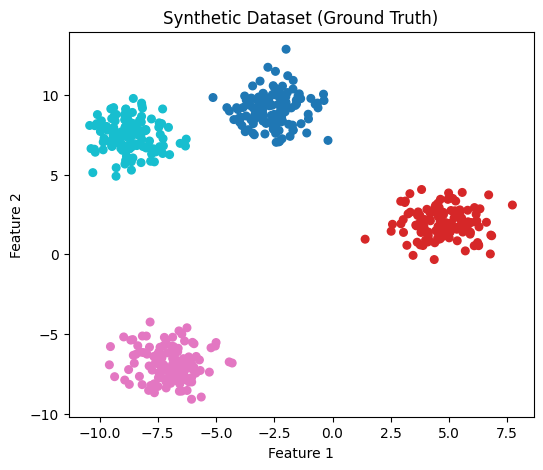

In [47]:
# Generate 2D synthetic clusters
X_synth, y_synth = make_blobs(
    n_samples=500,
    centers=4,
    n_features=2,
    cluster_std=1.0,
    random_state=42
)

# Visualize synthetic clusters (ground truth)
plt.figure(figsize=(6,5))
plt.scatter(X_synth[:,0], X_synth[:,1], c=y_synth, cmap='tab10', s=30)
plt.title("Synthetic Dataset (Ground Truth)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## K-means on Synthetic Data
We fit K-means to the synthetic dataset with 4 clusters and visualize the predicted clusters.

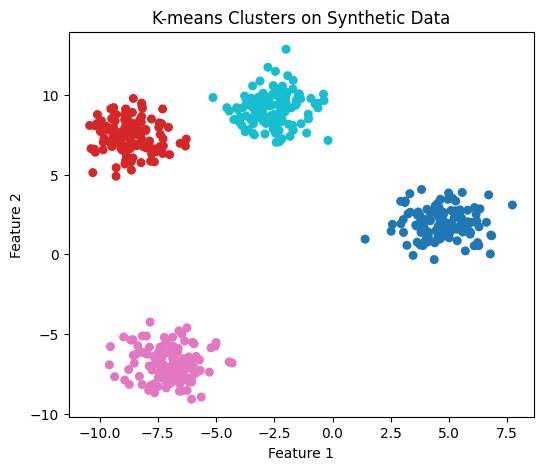

Adjusted Rand Index (synthetic): 1.0


In [48]:
# Fit K-means
kmeans_synth = KMeans(n_clusters=4, random_state=42)
kmeans_synth.fit(X_synth)
labels_synth = kmeans_synth.labels_

# Plot predicted clusters
plt.figure(figsize=(6,5))
plt.scatter(X_synth[:,0], X_synth[:,1], c=labels_synth, cmap='tab10', s=30)
plt.title("K-means Clusters on Synthetic Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Evaluate clustering quality using ARI
ari_synth = adjusted_rand_score(y_synth, labels_synth)
print("Adjusted Rand Index (synthetic):", ari_synth)

## Real Dataset: Digits
We apply K-means to the Digits dataset (8x8 images, 64 features).  
This tests K-means on a higher-dimensional, real-world dataset.

In [49]:
digits = load_digits()
X_digits = digits.data
y_digits = digits.target
print("Digits dataset shape:", X_digits.shape)

Digits dataset shape: (1797, 64)


## K-means on Digits Dataset
Since the data is high-dimensional, we also reduce it to 2D using PCA for visualization.

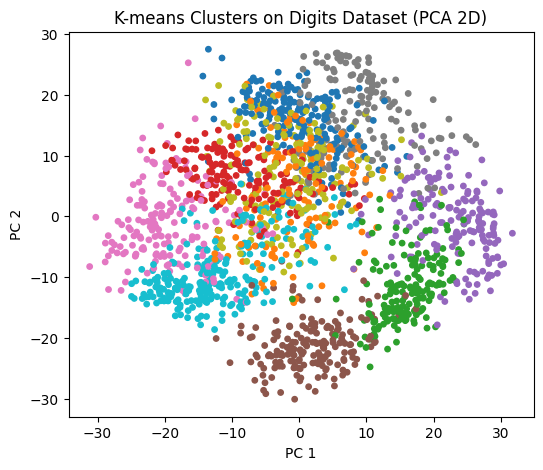

Adjusted Rand Index (digits): 0.725814218974996


In [50]:
# Fit K-means
kmeans_digits = KMeans(n_clusters=10, random_state=42)
kmeans_digits.fit(X_digits)
labels_digits = kmeans_digits.labels_

# PCA to 2D for visualization
pca = PCA(n_components=2)
X_digits_2d = pca.fit_transform(X_digits)

plt.figure(figsize=(6,5))
plt.scatter(X_digits_2d[:,0], X_digits_2d[:,1], c=labels_digits, cmap='tab10', s=15)
plt.title("K-means Clusters on Digits Dataset (PCA 2D)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()

# Evaluate clustering with ARI
ari_digits = adjusted_rand_score(y_digits, labels_digits)
print("Adjusted Rand Index (digits):", ari_digits)

## Hyperparameter Experiments
We explore how varying the number of clusters affects K-means performance on the synthetic dataset.

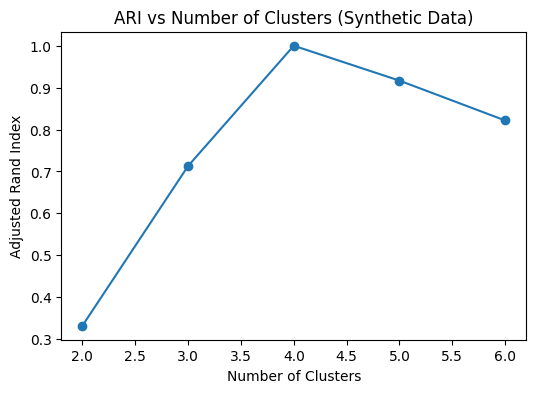

In [51]:
n_clusters_list = [2, 3, 4, 5, 6]
ari_scores = []

for n in n_clusters_list:
    kmeans = KMeans(n_clusters=n, random_state=42)
    kmeans.fit(X_synth)
    labels = kmeans.labels_
    ari = adjusted_rand_score(y_synth, labels)
    ari_scores.append(ari)

plt.figure(figsize=(6,4))
plt.plot(n_clusters_list, ari_scores, marker='o')
plt.title("ARI vs Number of Clusters (Synthetic Data)")
plt.xlabel("Number of Clusters")
plt.ylabel("Adjusted Rand Index")
plt.show()

## Discussion and Conclusion

**Key observations:**
- K-means successfully recovers the 4 synthetic clusters with ARI close to 1.
- On the Digits dataset, K-means finds meaningful structure but ARI is lower because clusters are not perfectly separable in feature space.
- Hyperparameter choice (`n_clusters`) significantly affects clustering quality.
- K-means assumptions: clusters are roughly spherical and similar in size; overlapping or elongated clusters reduce performance.

**Next steps / improvements:**
- Scale features or normalize before K-means.
- Try other clustering algorithms (Gaussian Mixture Models, DBSCAN).
- Apply K-means after dimensionality reduction (e.g., PCA) for large, high-dimensional datasets.